# GLUE Multi-Task Experiment: DistilRoBERTa with Frozen Base

**Goal:** Fine-tune only the classification head of `distilroberta-base` on 5 GLUE tasks, then extract all-layer embeddings from each fine-tuned model.

**Tasks:** CoLA, SST-2, MRPC, STS-B, QNLI

**Strategy:**
- Freeze all `model.roberta.*` parameters (backbone)
- Train only `model.classifier.*` (head)
- 10 epochs max, early stopping with patience=3 on `eval_loss`
- Extract embeddings from all layers (train+val concatenated) after each fine-tuning

**Model:** `distilroberta-base` — 6 encoder layers, hidden_size=768 (~82M params total, ~1.5M trainable)

**Note on STS-B:** STS-B is a regression task (predict similarity 0–5). `num_labels=1` triggers MSELoss automatically; labels are floats.

In [7]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, concatenate_datasets
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    DataCollatorWithPadding,
    Trainer,
    EarlyStoppingCallback,
)

from features_extraction import FeaturesExtraction, ExtractionConfig
from features_extraction.utils import setup_logging

setup_logging(level="WARNING")  # reduce verbosity during training

DEVICE = "mps"
assert torch.backends.mps.is_available(), "MPS backend not available on this machine"
print(f"Repo root: {REPO_ROOT}")
print(f"Device: {DEVICE}")
print("Setup complete.")

Repo root: /Users/insider/ITA/unstructured-data-metafeatures
Device: mps
Setup complete.


## Constants & GLUE Task Registry

In [2]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
BASE_MODEL   = "distilroberta-base"
NUM_EPOCHS   = 10
LR           = 2e-5
TRAIN_BATCH  = 16
EVAL_BATCH   = 32
WARMUP_RATIO = 0.06
WEIGHT_DECAY = 0.01
MAX_LENGTH   = 128
SEED         = 42
PATIENCE     = 3   # early stopping patience

# ── Output directories ────────────────────────────────────────────────────────
MODELS_DIR   = REPO_ROOT / "data" / "pretrained_models"
FEATURES_DIR = REPO_ROOT / "data" / "features"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# ── GLUE task registry ────────────────────────────────────────────────────────
GLUE_TASKS = {
    "cola": {
        "dataset_key":   "cola",
        "input_fields":  ["sentence"],
        "num_labels":    2,
        "is_regression": False,
        "metric_key":    "matthews_corrcoef",
    },
    "sst2": {
        "dataset_key":   "sst2",
        "input_fields":  ["sentence"],
        "num_labels":    2,
        "is_regression": False,
        "metric_key":    "accuracy",
    },
    "mrpc": {
        "dataset_key":   "mrpc",
        "input_fields":  ["sentence1", "sentence2"],
        "num_labels":    2,
        "is_regression": False,
        "metric_key":    "accuracy_f1",
    },
    "stsb": {
        "dataset_key":   "stsb",
        "input_fields":  ["sentence1", "sentence2"],
        "num_labels":    1,      # regression — scalar output
        "is_regression": True,
        "metric_key":    "pearson_spearman",
    },
    "qnli": {
        "dataset_key":   "qnli",
        "input_fields":  ["question", "sentence"],
        "num_labels":    2,
        "is_regression": False,
        "metric_key":    "accuracy",
    },
}

TASKS = list(GLUE_TASKS.keys())
print(f"Tasks: {TASKS}")

Tasks: ['cola', 'sst2', 'mrpc', 'stsb', 'qnli']


## Tokenization Functions

Two sets of tokenizers:
1. **`TOKENIZE_FNS`** — used by `FeaturesExtraction.extract_all_layers()` (signature: `(tokenizer, batch, max_length) -> dict`, raw text columns must remain in dataset)
2. **`prepare_glue_dataset()`** — used by HF Trainer (pre-tokenizes, removes text columns, renames `label` → `labels`)

In [3]:
# ── FeaturesExtraction tokenize_fn factory ────────────────────────────────────
def make_tokenize_single(field: str):
    """Factory: single-sentence tokenizer (CoLA, SST-2)."""
    def tokenize_fn(tokenizer, batch, max_length):
        return tokenizer(
            batch[field],
            padding="longest",
            truncation=True,
            max_length=max_length,
        )
    return tokenize_fn


def make_tokenize_pair(field1: str, field2: str):
    """Factory: sentence-pair tokenizer (MRPC, STS-B, QNLI)."""
    def tokenize_fn(tokenizer, batch, max_length):
        return tokenizer(
            batch[field1],
            batch[field2],
            padding="longest",
            truncation=True,
            max_length=max_length,
        )
    return tokenize_fn


TOKENIZE_FNS = {
    "cola": make_tokenize_single("sentence"),
    "sst2": make_tokenize_single("sentence"),
    "mrpc": make_tokenize_pair("sentence1", "sentence2"),
    "stsb": make_tokenize_pair("sentence1", "sentence2"),
    "qnli": make_tokenize_pair("question", "sentence"),
}


# ── Trainer-side dataset preparation ─────────────────────────────────────────
def prepare_glue_dataset(task_name: str, split_dataset, tokenizer, max_length: int):
    """Tokenize a GLUE split and format it for HF Trainer."""
    fields = GLUE_TASKS[task_name]["input_fields"]

    def _tok(batch):
        if len(fields) == 1:
            return tokenizer(
                batch[fields[0]],
                padding="max_length",
                truncation=True,
                max_length=max_length,
            )
        else:
            return tokenizer(
                batch[fields[0]],
                batch[fields[1]],
                padding="max_length",
                truncation=True,
                max_length=max_length,
            )

    cols_to_remove = [c for c in split_dataset.column_names if c not in {"label", "labels"}]
    tokenized = split_dataset.map(_tok, batched=True, remove_columns=cols_to_remove)

    if "label" in tokenized.column_names:
        tokenized = tokenized.rename_column("label", "labels")

    tokenized.set_format("torch")
    return tokenized


print("Tokenization helpers defined.")

Tokenization helpers defined.


## Task-Specific Metrics

Root `utils.compute_metrics` is not reused — it only handles generic classification and can't handle STS-B regression or CoLA's Matthews correlation.

In [4]:
def compute_metrics_classification(eval_pred):
    """Accuracy + F1 for standard classification tasks (SST-2, MRPC, QNLI)."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    average = "binary" if len(np.unique(labels)) == 2 else "weighted"
    return {
        "accuracy": float(accuracy_score(labels, preds)),
        "f1":       float(f1_score(labels, preds, average=average, zero_division=0)),
    }


def compute_metrics_cola(eval_pred):
    """Matthews Correlation Coefficient for CoLA."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"matthews_corrcoef": float(matthews_corrcoef(labels, preds))}


def compute_metrics_stsb(eval_pred):
    """Pearson + Spearman correlation for STS-B regression."""
    preds, labels = eval_pred
    preds = preds.squeeze()  # [N,1] → [N]
    pearson_r,  _ = pearsonr(preds, labels)
    spearman_r, _ = spearmanr(preds, labels)
    return {
        "pearson":  float(pearson_r),
        "spearman": float(spearman_r),
    }


COMPUTE_METRICS_FNS = {
    "cola": compute_metrics_cola,
    "sst2": compute_metrics_classification,
    "mrpc": compute_metrics_classification,
    "stsb": compute_metrics_stsb,
    "qnli": compute_metrics_classification,
}

print("Metric functions defined.")

Metric functions defined.


## Freeze Helper & Fine-Tuning Function

In [5]:
def freeze_base(model):
    """Freeze all model.roberta.* parameters; keep classifier.* trainable."""
    for name, param in model.named_parameters():
        param.requires_grad = not name.startswith("roberta.")

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
    return model


def finetune_task(task_name: str, train_ds, val_ds, tokenizer, task_cfg: dict):
    """Fine-tune classification head on one GLUE task."""
    ckpt_dir   = MODELS_DIR / f"distilroberta_{task_name}_checkpoints"
    output_dir = MODELS_DIR / f"distilroberta_{task_name}_head_only"

    model = AutoModelForSequenceClassification.from_pretrained(
        BASE_MODEL, num_labels=task_cfg["num_labels"]
    )
    print("  Freezing backbone:")
    model = freeze_base(model)

    training_args = TrainingArguments(
        output_dir=str(ckpt_dir),
        num_train_epochs=NUM_EPOCHS,
        learning_rate=LR,
        per_device_train_batch_size=TRAIN_BATCH,
        per_device_eval_batch_size=EVAL_BATCH,
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=2,
        report_to="none",
        seed=SEED,
        use_mps_device=True,
    )

    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=collator,
        compute_metrics=COMPUTE_METRICS_FNS[task_name],
        callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
    )

    trainer.train()
    eval_results = trainer.evaluate()

    output_dir.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(output_dir))
    tokenizer.save_pretrained(str(output_dir))

    return model, trainer, eval_results


print("Fine-tuning helpers defined.")

Fine-tuning helpers defined.


## Fine-Tuning Loop

In [6]:
all_results     = {}  # {task_name: eval_results dict}
trained_models  = {}  # {task_name: best model}
trained_trainers = {} # {task_name: Trainer (for log_history)}

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

for task_name, task_cfg in GLUE_TASKS.items():
    print(f"\n{'='*70}")
    print(f"Task: {task_name.upper()}")
    print(f"{'='*70}")

    train_raw = load_dataset("glue", task_cfg["dataset_key"], split="train")
    val_raw   = load_dataset("glue", task_cfg["dataset_key"], split="validation")
    print(f"  Train: {len(train_raw):,} | Val: {len(val_raw):,}")

    train_tok = prepare_glue_dataset(task_name, train_raw, tokenizer, MAX_LENGTH)
    val_tok   = prepare_glue_dataset(task_name, val_raw,   tokenizer, MAX_LENGTH)

    model, trainer, eval_results = finetune_task(
        task_name, train_tok, val_tok, tokenizer, task_cfg
    )

    all_results[task_name]      = eval_results
    trained_models[task_name]   = model
    trained_trainers[task_name] = trainer

    print(f"  Eval: {eval_results}")

print("\nAll fine-tuning complete.")


Task: COLA
  Train: 8,551 | Val: 1,043


Map: 100%|██████████| 1043/1043 [00:00<00:00, 29535.96 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/insider/ITA/unstructured-data-metafeatures/.venv/lib/python3.11/site-packages/transformers/training_args.py:2301: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/var/folders/ff/lyy0zjdd1gz_gpdk3cpwnlpw0000gn/T/ipykernel_59068/855722546.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `proce

  Freezing backbone:
  Trainable: 592,130 / 82,119,938 (0.72%)


/Users/insider/ITA/unstructured-data-metafeatures/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Matthews Corrcoef
1,0.625400,0.613810,0.000000
2,0.606800,0.613197,0.000000
3,0.602100,0.608594,0.000000
4,0.600700,0.611090,0.000000
5,0.595700,0.605749,0.000000
6,0.590000,0.603174,0.000000
7,0.595600,0.600918,0.000000
8,0.595800,0.602866,0.000000
9,0.592900,0.601482,0.000000
10,0.589100,0.601234,0.000000


...

Map: 100%|██████████| 5463/5463 [00:00<00:00, 27394.84 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/insider/ITA/unstructured-data-metafeatures/.venv/lib/python3.11/site-packages/transformers/training_args.py:2301: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/var/folders/ff/lyy0zjdd1gz_gpdk3cpwnlpw0000gn/T/ipykernel_59068/855722546.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `proce

  Freezing backbone:
  Trainable: 592,130 / 82,119,938 (0.72%)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.683700,0.681005,0.553725,0.659877
2,0.671100,0.665424,0.622552,0.618854
3,0.666800,0.655745,0.630972,0.611261
4,0.662400,0.649031,0.635548,0.630269
5,0.661700,0.645436,0.633718,0.676475
6,0.660400,0.643432,0.637928,0.608936
7,0.660500,0.640248,0.651474,0.641161
8,0.655900,0.639011,0.650924,0.634604
9,0.654600,0.638158,0.651840,0.637852
10,0.662900,0.638543,0.646897,0.623316


/Users/insider/ITA/unstructured-data-metafeatures/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/insider/ITA/unstructured-data-metafeatures/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/insider/ITA/unstructured-data-metafeatures/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/insider/ITA/unstructured-data-metafeatures/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pin

  Eval: {'eval_loss': 0.6381579637527466, 'eval_accuracy': 0.6518396485447556, 'eval_f1': 0.6378522467631379, 'eval_runtime': 21.0524, 'eval_samples_per_second': 259.496, 'eval_steps_per_second': 8.123, 'epoch': 10.0}

All fine-tuning complete.


## Fine-Tuning Results Summary

In [ ]:
print(f"{'Task':<8} {'Loss':>10} {'Metric':>22} {'Value':>15}")
print("-" * 60)

for task_name, res in all_results.items():
    metric_key = GLUE_TASKS[task_name]["metric_key"]
    loss_val   = res.get("eval_loss", float("nan"))

    if metric_key == "accuracy_f1":
        value_str = f"acc={res.get('eval_accuracy', 0):.3f} f1={res.get('eval_f1', 0):.3f}"
    elif metric_key == "pearson_spearman":
        value_str = f"r={res.get('eval_pearson', 0):.3f} rho={res.get('eval_spearman', 0):.3f}"
    elif metric_key == "matthews_corrcoef":
        value_str = f"{res.get('eval_matthews_corrcoef', 0):.3f}"
    else:
        value_str = f"{res.get(f'eval_{metric_key}', 0):.3f}"

    print(f"{task_name:<8} {loss_val:>10.4f} {metric_key:>22} {value_str:>15}")

## Training Curves

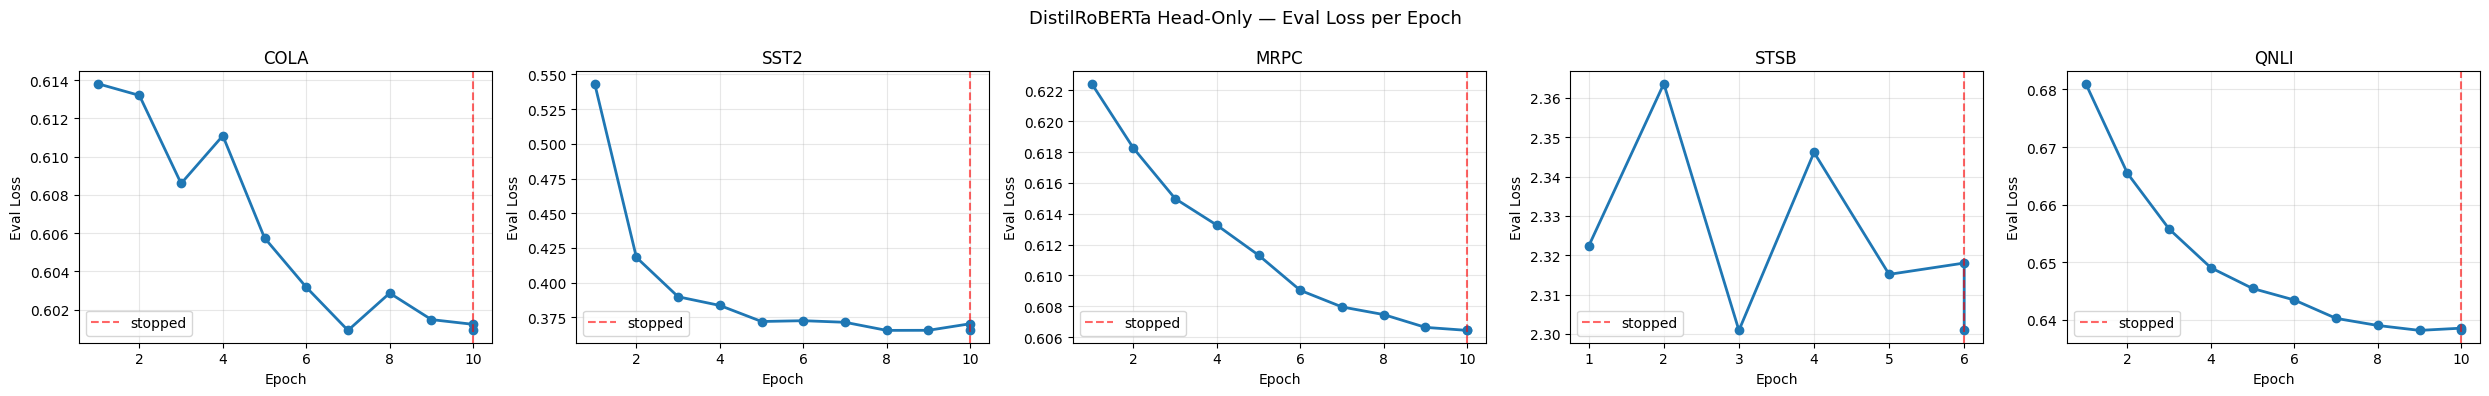

Saved: /Users/insider/ITA/unstructured-data-metafeatures/data/features/distilroberta_training_curves.png


In [8]:
fig, axes = plt.subplots(1, len(GLUE_TASKS), figsize=(5 * len(GLUE_TASKS), 4))

for ax, (task_name, trainer) in zip(axes, trained_trainers.items()):
    log_history = trainer.state.log_history
    eval_logs   = [l for l in log_history if "eval_loss" in l]
    if not eval_logs:
        ax.set_title(f"{task_name.upper()} — no eval logs")
        continue
    epochs = [l["epoch"] for l in eval_logs]
    losses = [l["eval_loss"] for l in eval_logs]

    ax.plot(epochs, losses, marker="o", linewidth=2)
    ax.axvline(x=epochs[-1], color="red", linestyle="--", alpha=0.6, label="stopped")
    ax.set_title(f"{task_name.upper()}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Eval Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("DistilRoBERTa Head-Only — Eval Loss per Epoch", fontsize=13)
plt.tight_layout()
plt.savefig(str(FEATURES_DIR / "distilroberta_training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FEATURES_DIR / 'distilroberta_training_curves.png'}")

## Feature Extraction

For each fine-tuned model:
- Concatenate train + validation splits
- Extract embeddings from **all hidden states** using `FeaturesExtraction.extract_all_layers()`
  - DistilRoBERTa: 8 states total — `["input", "layer_0", ..., "layer_5", "embeddings"]`
- Pooling: `mean` (respects attention mask)
- Save to `data/features/{task}_distilroberta_allsplits_features.npz`

**Note on STS-B labels:** STS-B labels are float (similarity 0–5). The saved `.npz` will have `dtype=float32` for labels on this task.

In [10]:
def extract_task_features(task_name: str, model, tokenizer):
    """Extract all-layer mean-pooled embeddings for a task (train+val)."""
    task_cfg = GLUE_TASKS[task_name]

    train_raw = load_dataset("glue", task_cfg["dataset_key"], split="train")
    val_raw   = load_dataset("glue", task_cfg["dataset_key"], split="validation")
    full_ds   = concatenate_datasets([train_raw, val_raw])
    print(f"  {task_name}: {len(train_raw):,} train + {len(val_raw):,} val = {len(full_ds):,} total")

    output_path = str(FEATURES_DIR / f"{task_name}_distilroberta_allsplits_features.npz")

    config = ExtractionConfig(
        batch_size=8,
        max_length=MAX_LENGTH,
        device=DEVICE,
        pooling="mean",
        return_numpy=True,
        output_path=output_path,
    )

    extractor = FeaturesExtraction(model, tokenizer)
    features_by_layer, labels = extractor.extract_all_layers(
        dataset=full_ds,
        tokenize_fn=TOKENIZE_FNS[task_name],
        config=config,
    )

    first_key = list(features_by_layer.keys())[0]
    print(f"  Layers: {list(features_by_layer.keys())}")
    print(f"  Shape/layer: {features_by_layer[first_key].shape}")
    print(f"  Labels dtype: {labels.dtype if labels is not None else 'N/A'}")
    print(f"  Saved → {output_path}")

    return features_by_layer, labels


print("Feature extraction helper defined.")

Feature extraction helper defined.


## Feature Extraction Loop

In [11]:
all_features   = {}  # {task_name: features_by_layer dict}
all_labels_map = {}  # {task_name: labels array}

# Extract smaller datasets first, then larger ones
extraction_order = ["cola", "mrpc", "stsb", "sst2", "qnli"]

for task_name in extraction_order:
    print(f"\n{'='*60}")
    print(f"Extracting: {task_name.upper()}")
    print(f"{'='*60}")

    model     = trained_models[task_name]
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

    features_by_layer, labels = extract_task_features(task_name, model, tokenizer)

    all_features[task_name]   = features_by_layer
    all_labels_map[task_name] = labels

    # Confirm file saved immediately
    fpath = FEATURES_DIR / f"{task_name}_distilroberta_allsplits_features.npz"
    size_mb = fpath.stat().st_size / 1e6 if fpath.exists() else 0
    print(f"  Saved: {fpath.name} ({size_mb:.1f} MB)")

print("\nFeature extraction complete.")
print("\nAll saved files:")
for task_name in extraction_order:
    fpath = FEATURES_DIR / f"{task_name}_distilroberta_allsplits_features.npz"
    size_mb = fpath.stat().st_size / 1e6 if fpath.exists() else 0
    print(f"  {fpath.name}: {size_mb:.1f} MB")



Extracting: COLA
  cola: 8,551 train + 1,043 val = 9,594 total


Tokenizing dataset: 100%|██████████| 9594/9594 [00:00<00:00, 79123.18 examples/s]


  Layers: ['input', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'embeddings']
  Shape/layer: (9594, 768)
  Labels dtype: int64
  Saved → /Users/insider/ITA/unstructured-data-metafeatures/data/features/cola_distilroberta_allsplits_features.npz
  Saved: cola_distilroberta_allsplits_features.npz (191.6 MB)

Extracting: MRPC
  mrpc: 3,668 train + 408 val = 4,076 total


Tokenizing dataset: 100%|██████████| 4076/4076 [00:00<00:00, 28247.69 examples/s]


  Layers: ['input', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'embeddings']
  Shape/layer: (4076, 768)
  Labels dtype: int64
  Saved → /Users/insider/ITA/unstructured-data-metafeatures/data/features/mrpc_distilroberta_allsplits_features.npz
  Saved: mrpc_distilroberta_allsplits_features.npz (81.5 MB)

Extracting: STSB
  stsb: 5,749 train + 1,500 val = 7,249 total


...

  Layers: ['input', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'embeddings']
  Shape/layer: (7249, 768)
  Labels dtype: float32
  Saved → /Users/insider/ITA/unstructured-data-metafeatures/data/features/stsb_distilroberta_allsplits_features.npz
  Saved: stsb_distilroberta_allsplits_features.npz (144.7 MB)

Extracting: SST2
  sst2: 67,349 train + 872 val = 68,221 total


Tokenizing dataset: 100%|██████████| 68221/68221 [00:01<00:00, 67749.61 examples/s]


  Layers: ['input', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'embeddings']
  Shape/layer: (68221, 768)
  Labels dtype: int64
  Saved → /Users/insider/ITA/unstructured-data-metafeatures/data/features/sst2_distilroberta_allsplits_features.npz
  Saved: sst2_distilroberta_allsplits_features.npz (1364.4 MB)

Extracting: QNLI
  qnli: 104,743 train + 5,463 val = 110,206 total


Tokenizing dataset: 100%|██████████| 110206/110206 [00:03<00:00, 30028.21 examples/s]


  Layers: ['input', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'embeddings']
  Shape/layer: (110206, 768)
  Labels dtype: int64
  Saved → /Users/insider/ITA/unstructured-data-metafeatures/data/features/qnli_distilroberta_allsplits_features.npz
  Saved: qnli_distilroberta_allsplits_features.npz (2204.2 MB)

Feature extraction complete.

All saved files:
  cola_distilroberta_allsplits_features.npz: 191.6 MB
  mrpc_distilroberta_allsplits_features.npz: 81.5 MB
  stsb_distilroberta_allsplits_features.npz: 144.7 MB
  sst2_distilroberta_allsplits_features.npz: 1364.4 MB
  qnli_distilroberta_allsplits_features.npz: 2204.2 MB


## Verification

In [12]:
print("Verification of saved .npz files:\n")
for task_name in TASKS:
    fpath = FEATURES_DIR / f"{task_name}_distilroberta_allsplits_features.npz"
    if not fpath.exists():
        print(f"  {task_name.upper()}: FILE NOT FOUND")
        continue
    data = np.load(str(fpath), allow_pickle=True)

    layer_keys  = [k for k in data.files if k.startswith("features_")]
    label_dtype = data["labels"].dtype if "labels" in data.files else "N/A"
    first_shape = data[layer_keys[0]].shape if layer_keys else "N/A"

    task_type = "float (regression)" if GLUE_TASKS[task_name]["is_regression"] else "int (classification)"
    print(f"  {task_name.upper()}")
    print(f"    Layer arrays : {len(layer_keys)} | Names: {[k.replace('features_', '') for k in layer_keys]}")
    print(f"    Shape/layer  : {first_shape}")
    print(f"    Labels dtype : {label_dtype}  ({task_type})")
    print()

Verification of saved .npz files:

  COLA
    Layer arrays : 7 | Names: ['input', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'embeddings']
    Shape/layer  : (9594, 768)
    Labels dtype : int64  (int (classification))

  SST2
    Layer arrays : 7 | Names: ['input', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'embeddings']
    Shape/layer  : (68221, 768)
    Labels dtype : int64  (int (classification))

  MRPC
    Layer arrays : 7 | Names: ['input', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'embeddings']
    Shape/layer  : (4076, 768)
    Labels dtype : int64  (int (classification))

  STSB
    Layer arrays : 7 | Names: ['input', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'embeddings']
    Shape/layer  : (7249, 768)
    Labels dtype : float32  (float (regression))

  QNLI
    Layer arrays : 7 | Names: ['input', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'embeddings']
    Shape/layer  : (110206, 768)
    Labels dtype : int64  (

## Layer Shape Summary

In [13]:
print(f"{'Task':<8} {'#Samples':>10} {'#Layers':>8} {'Hidden Dim':>12}")
print("-" * 42)
for task_name, fbl in all_features.items():
    first_key  = list(fbl.keys())[0]
    n_samples  = fbl[first_key].shape[0]
    n_layers   = len(fbl)
    hidden_dim = fbl[first_key].shape[1]
    print(f"{task_name:<8} {n_samples:>10,} {n_layers:>8} {hidden_dim:>12}")

Task       #Samples  #Layers   Hidden Dim
------------------------------------------
cola          9,594        7          768
mrpc          4,076        7          768
stsb          7,249        7          768
sst2         68,221        7          768
qnli        110,206        7          768


## PCA Visualization — Last Layer Embeddings

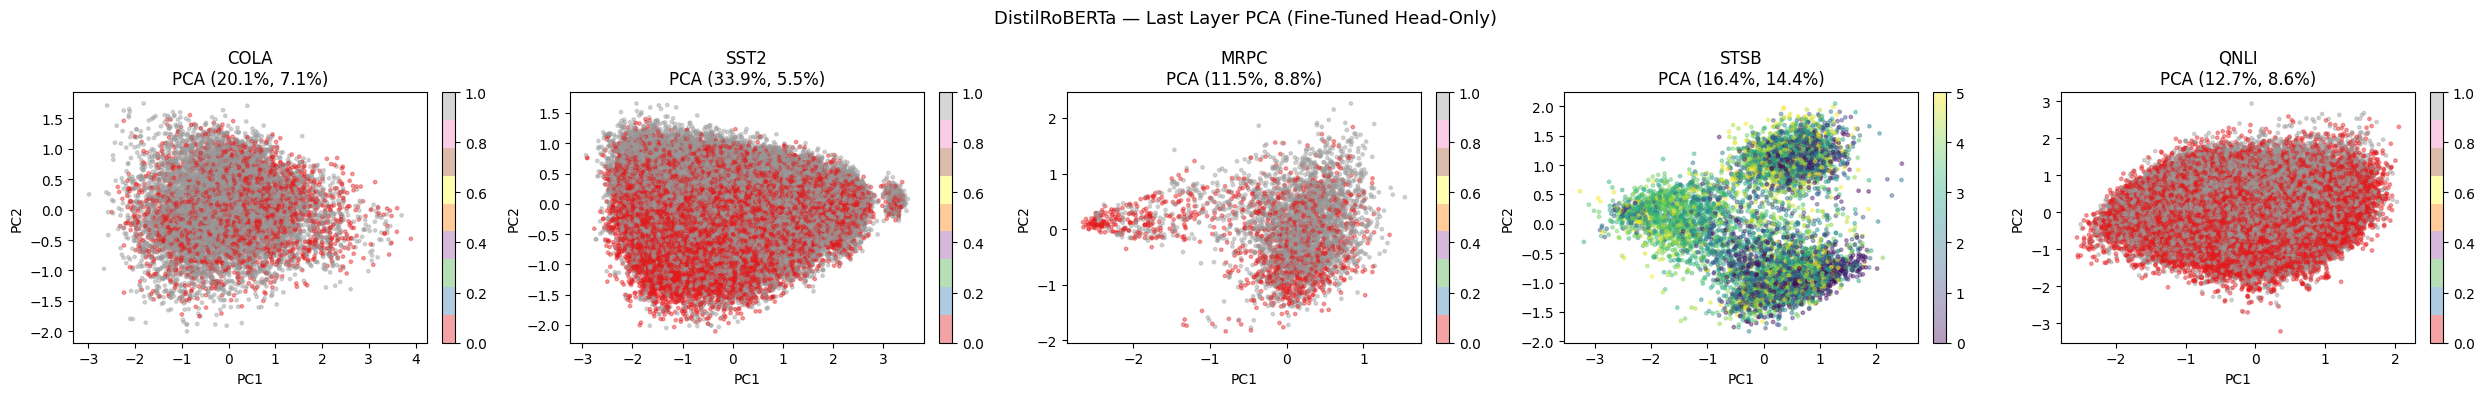

Saved: /Users/insider/ITA/unstructured-data-metafeatures/data/features/distilroberta_pca_allTasks.png


In [14]:
fig, axes = plt.subplots(1, len(TASKS), figsize=(5 * len(TASKS), 4))

for ax, task_name in zip(axes, TASKS):
    fbl    = all_features[task_name]
    labels = all_labels_map[task_name]

    # Use last layer ("embeddings" in this repo's naming convention)
    last_key = list(fbl.keys())[-1]
    X = fbl[last_key]

    pca  = PCA(n_components=2, random_state=SEED)
    X_2d = pca.fit_transform(X)
    var  = pca.explained_variance_ratio_

    cmap = "viridis" if GLUE_TASKS[task_name]["is_regression"] else "Set1"
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap=cmap, alpha=0.4, s=6)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"{task_name.upper()}\nPCA ({var[0]:.1%}, {var[1]:.1%})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("DistilRoBERTa — Last Layer PCA (Fine-Tuned Head-Only)", fontsize=13)
plt.tight_layout()
plt.savefig(str(FEATURES_DIR / "distilroberta_pca_allTasks.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FEATURES_DIR / 'distilroberta_pca_allTasks.png'}")

## Per-Layer Mean L2 Norm

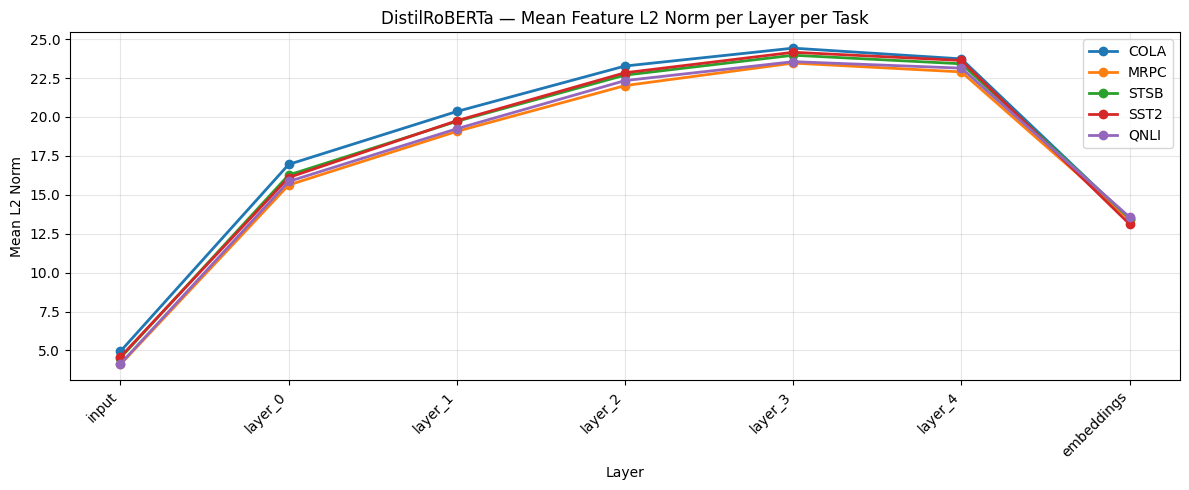

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

layer_names = list(next(iter(all_features.values())).keys())

for task_name, fbl in all_features.items():
    norms = [np.linalg.norm(fbl[l], axis=1).mean() for l in layer_names]
    ax.plot(range(len(layer_names)), norms, marker="o", linewidth=2, label=task_name.upper())

ax.set_xticks(range(len(layer_names)))
ax.set_xticklabels(layer_names, rotation=45, ha="right")
ax.set_xlabel("Layer")
ax.set_ylabel("Mean L2 Norm")
ax.set_title("DistilRoBERTa — Mean Feature L2 Norm per Layer per Task")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cross-Task Cosine Similarity per Layer

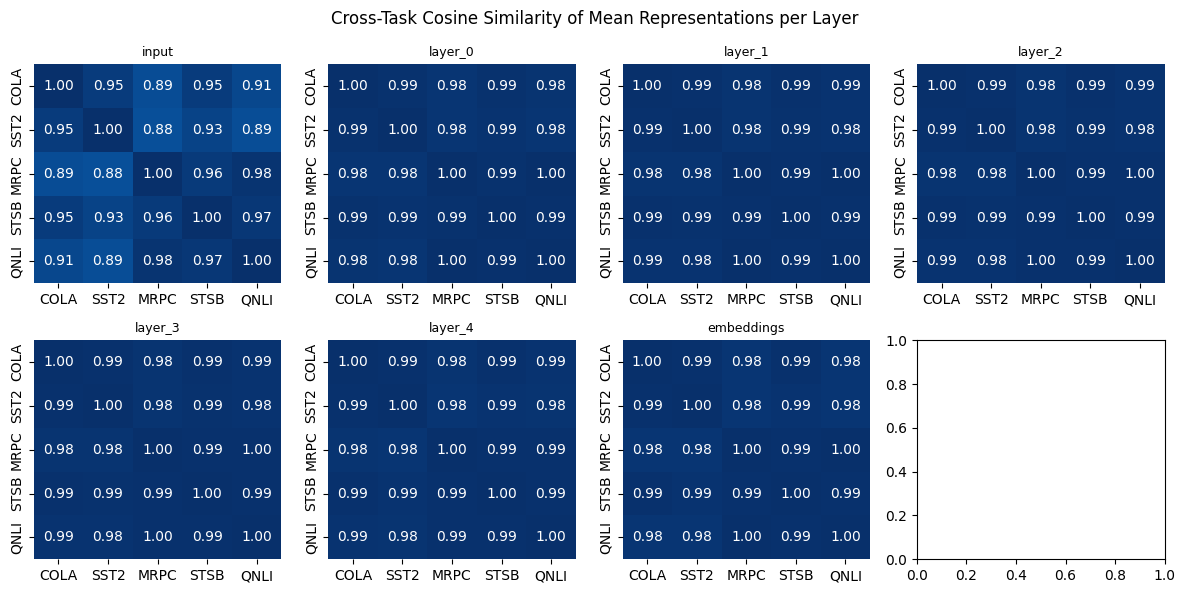

In [16]:
n_layers = len(layer_names)
ncols = min(4, n_layers)
nrows = (n_layers + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes_flat = axes.flat if nrows > 1 or ncols > 1 else [axes]

for ax, l in zip(axes_flat, layer_names):
    means = np.stack([all_features[t][l].mean(axis=0) for t in TASKS])
    sim   = cosine_similarity(means)
    sns.heatmap(
        sim, ax=ax, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=[t.upper() for t in TASKS],
        yticklabels=[t.upper() for t in TASKS],
        vmin=0, vmax=1, cbar=False,
    )
    ax.set_title(l, fontsize=9)

# Hide any unused subplots
for ax in list(axes_flat)[n_layers:]:
    ax.set_visible(False)

plt.suptitle("Cross-Task Cosine Similarity of Mean Representations per Layer", fontsize=12)
plt.tight_layout()
plt.show()

## Final Summary

In [17]:
rows = []
for task_name in TASKS:
    res    = all_results[task_name]
    fbl    = all_features[task_name]
    task   = GLUE_TASKS[task_name]

    first_key  = list(fbl.keys())[0]
    n_samples  = fbl[first_key].shape[0]
    n_layers   = len(fbl)
    hidden_dim = fbl[first_key].shape[1]
    fpath      = FEATURES_DIR / f"{task_name}_distilroberta_allsplits_features.npz"
    size_mb    = round(fpath.stat().st_size / 1e6, 1) if fpath.exists() else 0

    rows.append({
        "task":          task_name,
        "type":          "regression" if task["is_regression"] else "classification",
        "num_labels":    task["num_labels"],
        "eval_loss":     round(res.get("eval_loss", float("nan")), 4),
        "primary_metric": task["metric_key"],
        "n_samples":     n_samples,
        "n_layers":      n_layers,
        "hidden_dim":    hidden_dim,
        "features_file": fpath.name,
        "file_size_mb":  size_mb,
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

task           type  num_labels  eval_loss    primary_metric  n_samples  n_layers  hidden_dim                             features_file  file_size_mb
cola classification           2     0.6009 matthews_corrcoef       9594         7         768 cola_distilroberta_allsplits_features.npz         191.6
sst2 classification           2     0.3656          accuracy      68221         7         768 sst2_distilroberta_allsplits_features.npz        1364.4
mrpc classification           2     0.6064       accuracy_f1       4076         7         768 mrpc_distilroberta_allsplits_features.npz          81.5
stsb     regression           1     2.3009  pearson_spearman       7249         7         768 stsb_distilroberta_allsplits_features.npz         144.7
qnli classification           2     0.6382          accuracy     110206         7         768 qnli_distilroberta_allsplits_features.npz        2204.2


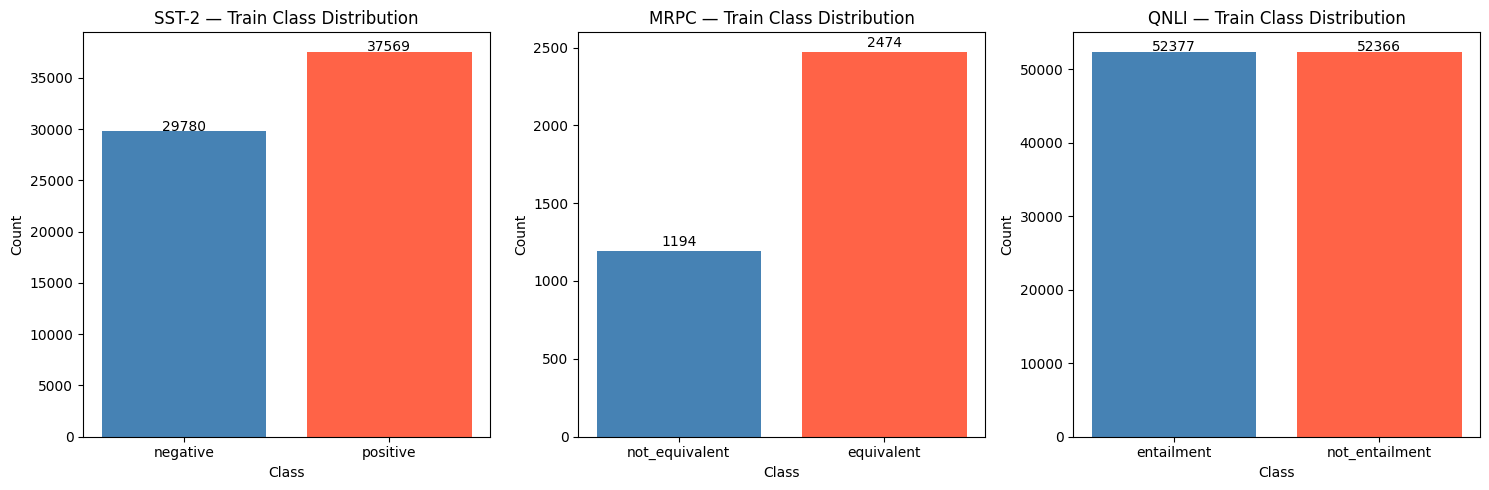

In [18]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import collections

datasets_info = {
    "SST-2": ("glue", "sst2", "sentence", None),
    "MRPC": ("glue", "mrpc", "sentence1", "sentence2"),
    "QNLI": ("glue", "qnli", "question", "sentence"),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, (path, config, col1, col2)) in zip(axes, datasets_info.items()):
    ds = load_dataset(path, config, split="train")
    counter = collections.Counter(ds["label"])
    label_names = ds.features["label"].names
    labels = [label_names[i] for i in sorted(counter)]
    counts = [counter[i] for i in sorted(counter)]

    ax.bar(labels, counts, color=["steelblue", "tomato", "mediumseagreen"][:len(labels)])
    ax.set_title(f"{name} — Train Class Distribution")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts):
        ax.text(i, v + 30, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()